In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
from models.attention_unet_3d import AttentionUNet3D
from utils.unets_helper_functions import (show_organ_overlay,
                    show_difference_map,
                    sliding_window_inference)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNet3D().to(device)
model_path = "../experiments/attention_unet_fold0/best_model.pth"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model loaded for testing.")


Model loaded for testing.


C:\Users\dhanu\AppData\Local\Temp\ipykernel_17240\822885626.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


In [4]:
FOLD = 0

with open(f"../data/splits/fold_{FOLD}/train.txt") as f:
    train_cases = f.read().splitlines()

with open(f"../data/splits/fold_{FOLD}/val.txt") as f:
    val_cases = f.read().splitlines()

In [5]:
case = val_cases[1]  # take second validation case
print("Testing case:", case)

image = nib.load(f"../data/processed/imagesTr/{case}.nii.gz").get_fdata()
label = nib.load(f"../data/processed/labelsTr/{case}.nii.gz").get_fdata()


Testing case: case_05


In [6]:
pred = sliding_window_inference(
    model,
    image,
    patch_size=80,
    stride=40,
    device=device
)

print("Prediction shape:", pred.shape)


Prediction shape: (243, 383, 383)


In [7]:
z = image.shape[0] // 2

ct_slice = image[z]
gt_slice = label[z]
pred_slice = pred[z]

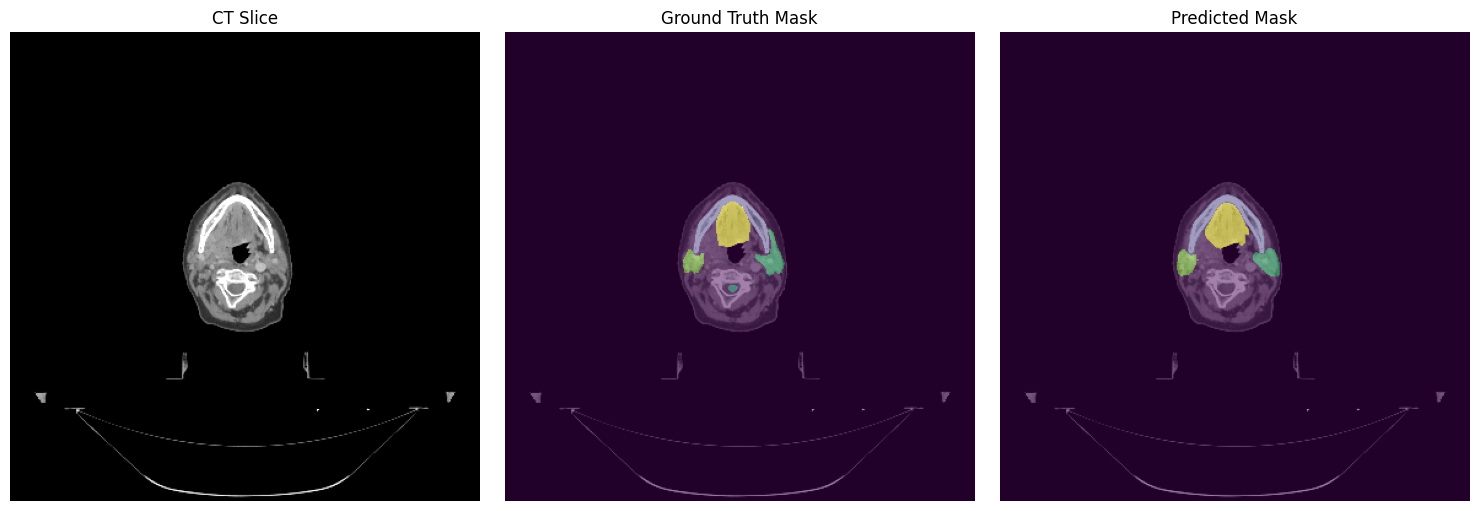

In [8]:
plt.figure(figsize=(15,5))

# CT
plt.subplot(1,3,1)
plt.imshow(ct_slice, cmap='gray')
plt.title("CT Slice")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.imshow(ct_slice, cmap='gray')
plt.imshow(gt_slice, alpha=0.5)
plt.title("Ground Truth Mask")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(ct_slice, cmap='gray')
plt.imshow(pred_slice, alpha=0.5)
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


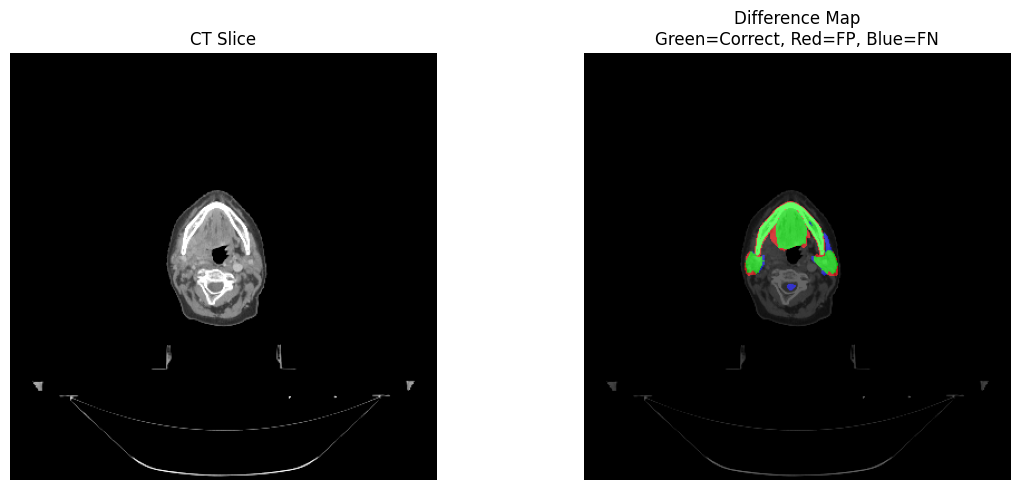

In [9]:
show_difference_map(ct_slice, gt_slice, pred_slice)

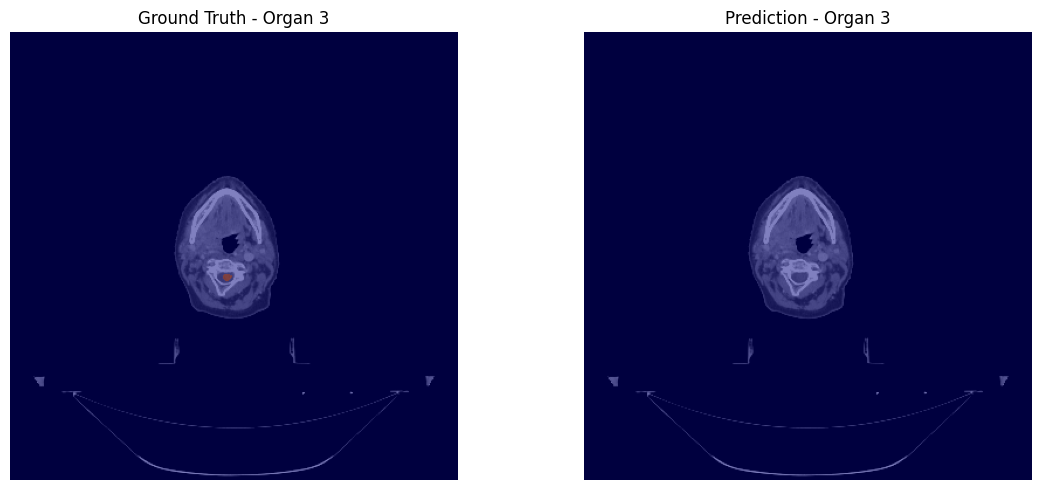

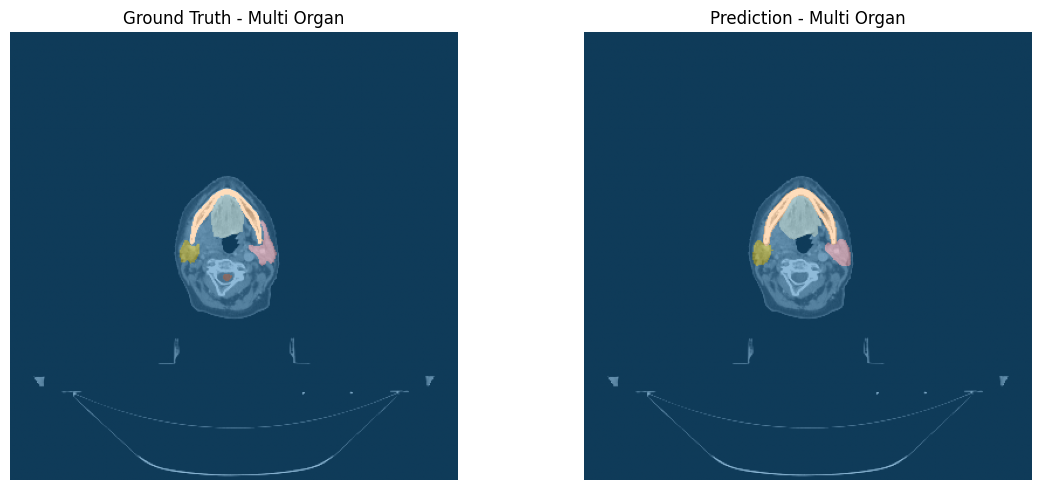

In [ ]:
show_organ_overlay(ct_slice, gt_slice, pred_slice,organ_id=3) #not working for spinal as expected
show_organ_overlay(ct_slice, gt_slice, pred_slice)

In [11]:
import ipywidgets as widgets
from IPython.display import display

def interactive_slice_viewer(volume, title="Volume"):

    def view_slice(z):
        plt.figure(figsize=(6,6))
        plt.imshow(volume[z], cmap='gray')
        plt.title(f"{title} - Slice {z}")
        plt.axis("off")
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=volume.shape[0]-1,
        step=1,
        value=volume.shape[0]//2
    )

    widgets.interact(view_slice, z=slider)


In [12]:
interactive_slice_viewer(image, title="CT")

interactive(children=(IntSlider(value=121, description='z', max=242), Output()), _dom_classes=('widget-interac…

In [13]:
interactive_slice_viewer(pred, title="Prediction")

interactive(children=(IntSlider(value=121, description='z', max=242), Output()), _dom_classes=('widget-interac…

In [14]:
interactive_slice_viewer(label, title="Ground Truth")

interactive(children=(IntSlider(value=121, description='z', max=242), Output()), _dom_classes=('widget-interac…